# 🧪 Categorizando variáveis contínuas


Agora vamos ligar este tema com a lógica de **categorização e binarização**.

O material da aula mostra que variáveis contínuas podem gerar distribuições confusas quando há muitos valores possíveis. Por isso, pode ser útil agrupá-las em poucas categorias ou em duas classes, desde que isso faça sentido para o contexto analítico fileciteturn0file0.

# 🏥 Criando um dataset simulado de saúde


Vamos construir um pequeno conjunto de dados com exemplos de variáveis:
- **Nominal**: sexo, tipo sanguíneo
- **Ordinal**: nível de dor, classificação de risco
- **Intervalar**: temperatura corporal em °C
- **Razão**: idade, peso, número de consultas, dias de internação

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [3]:
n = 120

df = pd.DataFrame({
    "sexo": np.random.choice(["F", "M"], size=n, p=[0.58, 0.42]),
    "tipo_sanguineo": np.random.choice(["A", "B", "AB", "O"], size=n, p=[0.36, 0.10, 0.05, 0.49]),
    "nivel_dor": np.random.choice(["Leve", "Moderada", "Intensa"], size=n, p=[0.45, 0.35, 0.20]),
    "classificacao_risco": np.random.choice(["Verde", "Amarelo", "Laranja", "Vermelho"], size=n, p=[0.45, 0.30, 0.18, 0.07]),
    "temperatura_c": np.round(np.random.normal(loc=36.8, scale=0.7, size=n), 1),
    "idade": np.random.randint(18, 91, size=n),
    "peso_kg": np.round(np.random.normal(loc=72, scale=14, size=n), 1),
    "num_consultas_ano": np.random.poisson(lam=4, size=n),
    "dias_internacao": np.random.poisson(lam=2, size=n)
})

df["peso_kg"] = df["peso_kg"].clip(lower=38)
df["temperatura_c"] = df["temperatura_c"].clip(lower=34.5, upper=40.5)

df.head()

,sexo,tipo_sanguineo,nivel_dor,classificacao_risco,temperatura_c,idade,peso_kg,num_consultas_ano,dias_internacao
0,F,O,Intensa,Verde,37.8,51,75.3,0,1
1,M,O,Intensa,Amarelo,37.5,25,82.8,1,1
2,M,A,Intensa,Amarelo,38.3,57,51.3,1,0
3,M,A,Leve,Amarelo,36.3,59,88.0,5,3
4,F,A,Leve,Vermelho,37.4,58,76.7,4,3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sexo                 120 non-null    object 
 1   tipo_sanguineo       120 non-null    object 
 2   nivel_dor            120 non-null    object 
 3   classificacao_risco  120 non-null    object 
 4   temperatura_c        120 non-null    float64
 5   idade                120 non-null    int64  
 6   peso_kg              120 non-null    float64
 7   num_consultas_ano    120 non-null    int64  
 8   dias_internacao      120 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 8.6+ KB


In [4]:
df.describe(include="all")

,sexo,tipo_sanguineo,nivel_dor,classificacao_risco,temperatura_c,idade,peso_kg,num_consultas_ano,dias_internacao
count,120,120,120,120,120.000000,120.000000,120.000000,120.000000,120.000000
unique,2,4,3,4,NaN,NaN,NaN,NaN,NaN
top,F,O,Leve,Verde,NaN,NaN,NaN,NaN,NaN
freq,71,59,49,54,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,36.812500,52.525000,72.616667,3.925000,1.858333
std,NaN,NaN,NaN,NaN,0.773355,22.204157,14.244275,2.013244,1.451142
min,NaN,NaN,NaN,NaN,35.200000,18.000000,38.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,36.275000,31.750000,64.375000,2.000000,1.000000
50%,NaN,NaN,NaN,NaN,36.800000,52.500000,71.950000,4.000000,2.000000
75%,NaN,NaN,NaN,NaN,37.325000,73.250000,82.025000,5.000000,3.000000


# 📦 Exemplo 1. Categorização da idade

In [5]:
bins_idade = [0, 29, 44, 59, 120]
labels_idade = ["18-29", "30-44", "45-59", "60+"]

df["faixa_etaria"] = pd.cut(df["idade"], bins=bins_idade, labels=labels_idade)

df["faixa_etaria"].value_counts().sort_index()

,count
faixa_etaria,
18-29,26
30-44,24
45-59,25
60+,45


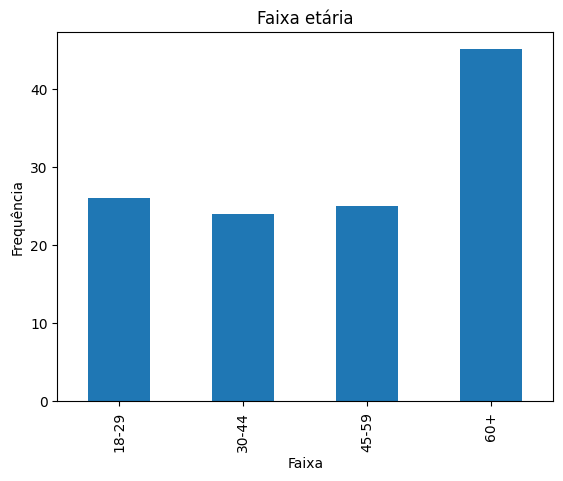

In [6]:
df["faixa_etaria"].value_counts().sort_index().plot(kind="bar")
plt.title("Faixa etária")
plt.xlabel("Faixa")
plt.ylabel("Frequência")
plt.show()

# ⚫ Exemplo 2. Binarização do peso


Aqui vamos criar uma variável binária simples:
- peso < 50 kg
- peso ≥ 50 kg

In [7]:
df["baixo_peso"] = np.where(df["peso_kg"] < 50, "Sim", "Não")
df["baixo_peso"].value_counts()

,count
baixo_peso,
Não,114
Sim,6


# 🌡️ Exemplo 3. Binarização da temperatura



Vamos separar:
- febre: temperatura ≥ 37.8°C
- sem febre: temperatura < 37.8°C

In [8]:
df["febre"] = np.where(df["temperatura_c"] >= 37.8, "Sim", "Não")
df["febre"].value_counts()

,count
febre,
Não,103
Sim,17


# 📐 Intervalo aberto e fechado

https://blog.professorferretto.com.br/intervalos-reais/

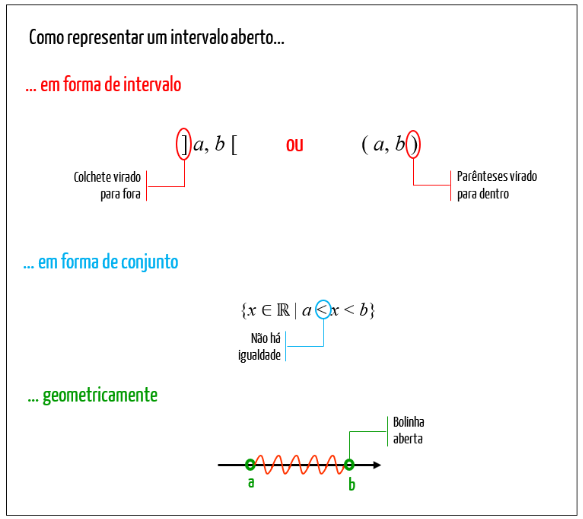

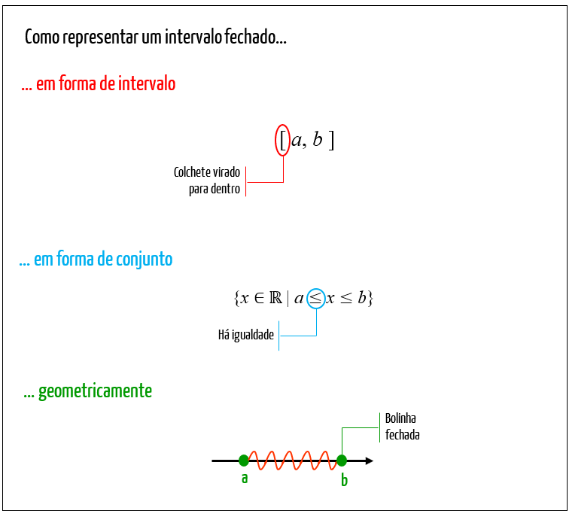

# 🤔 Mas quantas categorias?

Contudo, certas escolhas, tais como o tamanho do intervalo de pontuação (tamanho do grupo) e o número de grupos, se feita de forma arbitrária (ou intencional) pode afetar a natureza da distribuição de frequência final. Existem várias regras para ajudar a definir a quantidades de “bins” (classes) e o tamanho da amplitude de cada classe. A regra mais utilizada para isso é chamada de Regra Sturges.


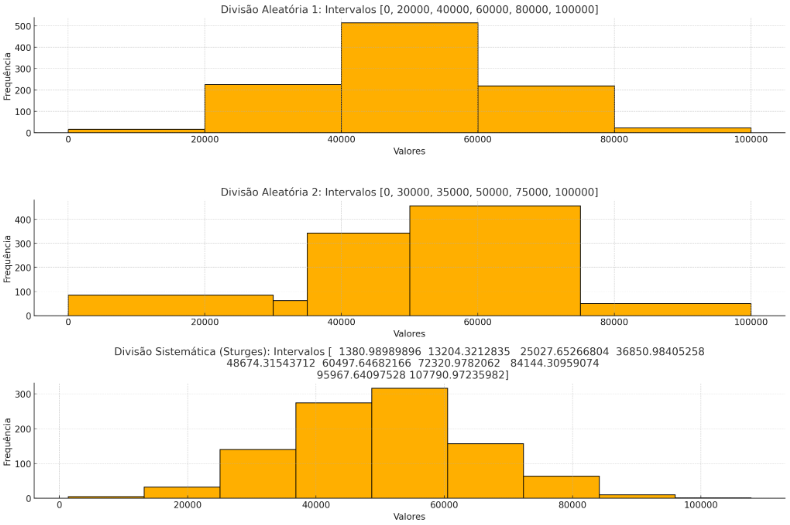

# 📐 Regra de Sturges em Python


A **Regra de Sturges** é apresentada como uma forma sistemática de definir o número de classes de uma variável contínua, evitando escolhas totalmente arbitrárias


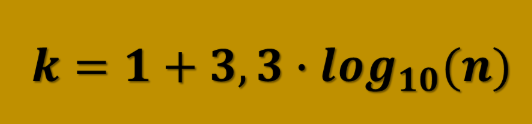

In [9]:
n = len(df)
k = round(1 + 3.3 * np.log10(n))
print("Número de observações:", n)
print("Número de classes pela Regra de Sturges:", k)

Número de observações: 120
Número de classes pela Regra de Sturges: 8


## 📊 Aplicando Sturges na variável idade

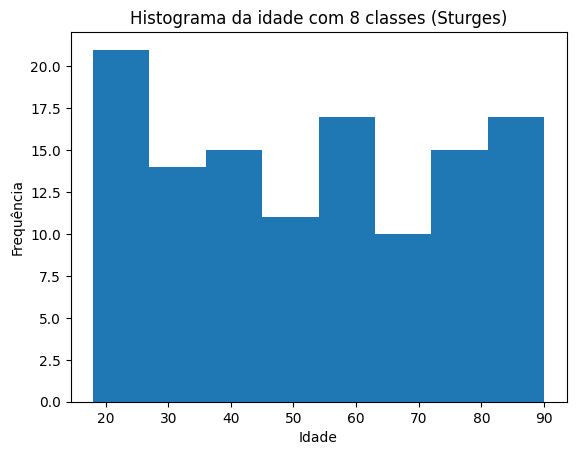

In [10]:
df["idade"].plot(kind="hist", bins=k)
plt.title(f"Histograma da idade com {k} classes (Sturges)")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

## 📊 Aplicando Sturges na variável peso

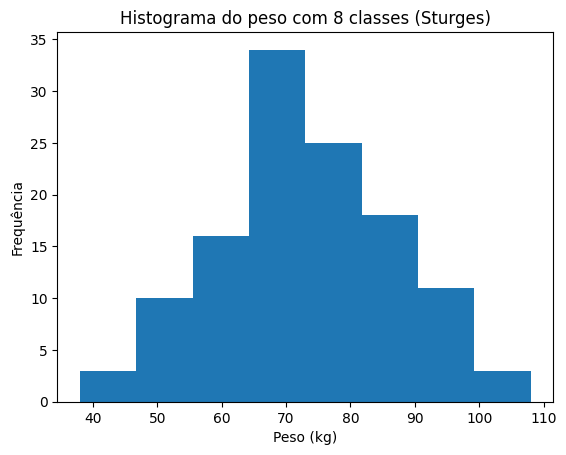

In [11]:
df["peso_kg"].plot(kind="hist", bins=k)
plt.title(f"Histograma do peso com {k} classes (Sturges)")
plt.xlabel("Peso (kg)")
plt.ylabel("Frequência")
plt.show()

# ⚠️ Quando categorizar e quando não categorizar?


**Pode ajudar quando:**
- queremos simplificar a comunicação
- há pontos de corte clínicos relevantes
- precisamos criar grupos interpretáveis
- a variável será usada em tabelas de frequência

**Pode atrapalhar quando:**
- perdemos informação
- escondemos variações importantes
- criamos grupos artificiais demais
.

Recomenda-se que, se já existir uma divisão clássica que funcione bem no contexto, ela pode ser usada. Em novos conjuntos de dados, vale preferir uma abordagem sistemática para evitar distorções, como a regra de Sturges

# 🧠 Takeaways


Se tiver que levar poucas ideias desta aula, leve estas:

- Nem toda variável pode ser analisada da mesma forma
- O nível de medida define quais operações fazem sentido
- Categorizar pode ajudar, mas também pode esconder informação
- Em saúde, pontos de corte clínicos podem ser úteis
- Quando não houver ponto de corte claro, uma regra sistemática pode ajudar na definição de classes, como a Regra de Sturges apresentada no material